In [1]:
!cd ~/c/iu9-sql-compiler/ && ./build-release/bin/benchmarks --benchmark_filter='^OperatorCost/' --benchmark_out=/tmp/operator-cost.json --benchmark_out_format=json

2026-05-31T16:14:53+03:00
Running ./build-release/bin/benchmarks
Run on (8 X 4200 MHz CPU s)
CPU Caches:
  L1 Data 48 KiB (x4)
  L1 Instruction 32 KiB (x4)
  L2 Unified 1280 KiB (x4)
  L3 Unified 8192 KiB (x1)
Load Average: 4.44, 2.58, 1.61
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.


---------------------------------------------------------------------------------------------------------------
Benchmark                                                     Time             CPU   Iterations UserCounters...
---------------------------------------------------------------------------------------------------------------
OperatorCost/SeqScan/1024/real_time                       79997 ns        78049 ns         8741 model_cost=102.4k output_rows=1.024k plan_cost=102.4k rows=1.024k
OperatorCost/SeqScan/2048/real_time                      144761 ns       142224 ns         5232 model_cost=204.8k output_rows=2.048k plan_cost=204.8k rows=2.048k
OperatorCost/SeqScan/4096/real_time                      338605 ns       327024 ns         2056 model_cost=409.6k output_rows=4.096k plan_cost=409.6k rows=4.096k
OperatorCost/SeqScan/8192/real_time                      813515 ns       787366 ns          726 model_cost=819.2k output_rows=8.192k plan_cost=819.2k rows=8.192k
OperatorCost/Seq

In [2]:
!ls -l /tmp | grep operator-cost

-rw-r--r--  1 st     users   40311 May 31 16:16 operator-cost.json
-rw-r--r--  1 st     users   33223 May 31 16:03 operator-cost-matched-calibrated-smoke.json
-rw-r--r--  1 st     users   33307 May 31 16:13 operator-cost-matched.json
-rw-r--r--  1 st     users    6149 May 31 15:08 operator-cost-matched-plan-cost-smoke.json
-rw-r--r--  1 st     users    2010 May 30 19:02 operator-cost-smoke.json


In [3]:
import json

results = None
with open('/tmp/operator-cost.json') as f:
    results = json.load(f)

results

{'context': {'date': '2026-05-31T16:14:53+03:00',
  'host_name': 'nixos',
  'executable': './build-release/bin/benchmarks',
  'num_cpus': 8,
  'mhz_per_cpu': 4200,
  'cpu_scaling_enabled': True,
  'caches': [{'type': 'Data', 'level': 1, 'size': 49152, 'num_sharing': 2},
   {'type': 'Instruction', 'level': 1, 'size': 32768, 'num_sharing': 2},
   {'type': 'Unified', 'level': 2, 'size': 1310720, 'num_sharing': 2},
   {'type': 'Unified', 'level': 3, 'size': 8388608, 'num_sharing': 8}],
  'load_avg': [4.44287, 2.58252, 1.60791],
  'library_version': 'v1.9.0',
  'library_build_type': 'release',
  'json_schema_version': 1},
 'benchmarks': [{'name': 'OperatorCost/SeqScan/1024/real_time',
   'family_index': 0,
   'per_family_instance_index': 0,
   'run_name': 'OperatorCost/SeqScan/1024/real_time',
   'run_type': 'iteration',
   'repetitions': 1,
   'repetition_index': 0,
   'threads': 1,
   'iterations': 8741,
   'real_time': 79996.77325230725,
   'cpu_time': 78049.49124814094,
   'time_unit': 

In [4]:
import pandas as pd

assert results

df = pd.DataFrame(results['benchmarks'])
df = df[df['run_type'] == 'iteration'].copy()

parts = df['name'].str.split('/')
df['operator'] = parts.str[1]
df['left_rows'] = parts.str[2].astype(int)
df['right_rows'] = parts.apply(lambda p: int(p[3]) if len(p) == 5 else None)

df['real_time_ms'] = df['real_time'] / 1e6

df[['operator', 'left_rows', 'right_rows', 'real_time_ms', 'model_cost']].sort_values(['operator', 'left_rows'])

,operator,left_rows,right_rows,real_time_ms,model_cost
36,Aggregation,1024,NaN,0.367198,522240.0
37,Aggregation,2048,NaN,0.714949,1044480.0
38,Aggregation,4096,NaN,1.378878,2088960.0
39,Aggregation,8192,NaN,2.970154,4177920.0
40,Aggregation,16384,NaN,7.566779,8355840.0
...,...,...,...,...,...
31,Sort,16384,NaN,4.673407,2703360.0
32,Sort,32768,NaN,10.560526,5767168.0
33,Sort,65536,NaN,27.512323,12255232.0
34,Sort,131072,NaN,76.878972,25952256.0


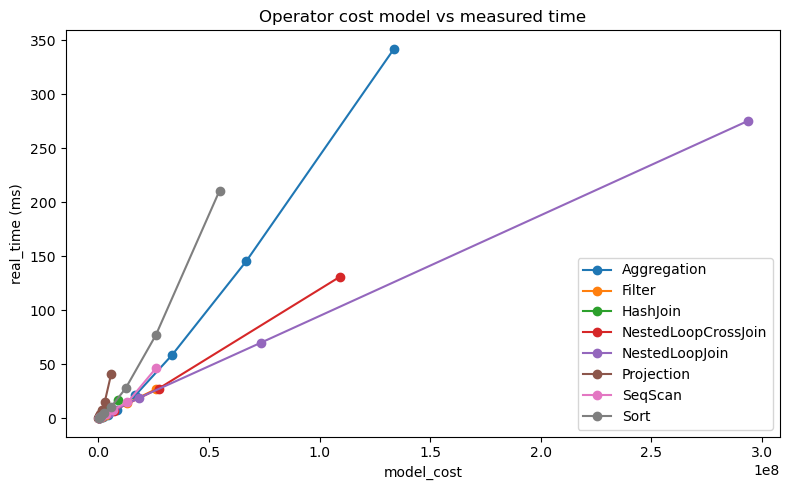

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for op, grp in df.groupby('operator'):
    ax.plot(grp['model_cost'], grp['real_time_ms'], marker='o', label=op)

ax.set_xlabel('model_cost')
ax.set_ylabel('real_time (ms)')
ax.set_title('Operator cost model vs measured time')
ax.legend()
plt.tight_layout()
plt.show()

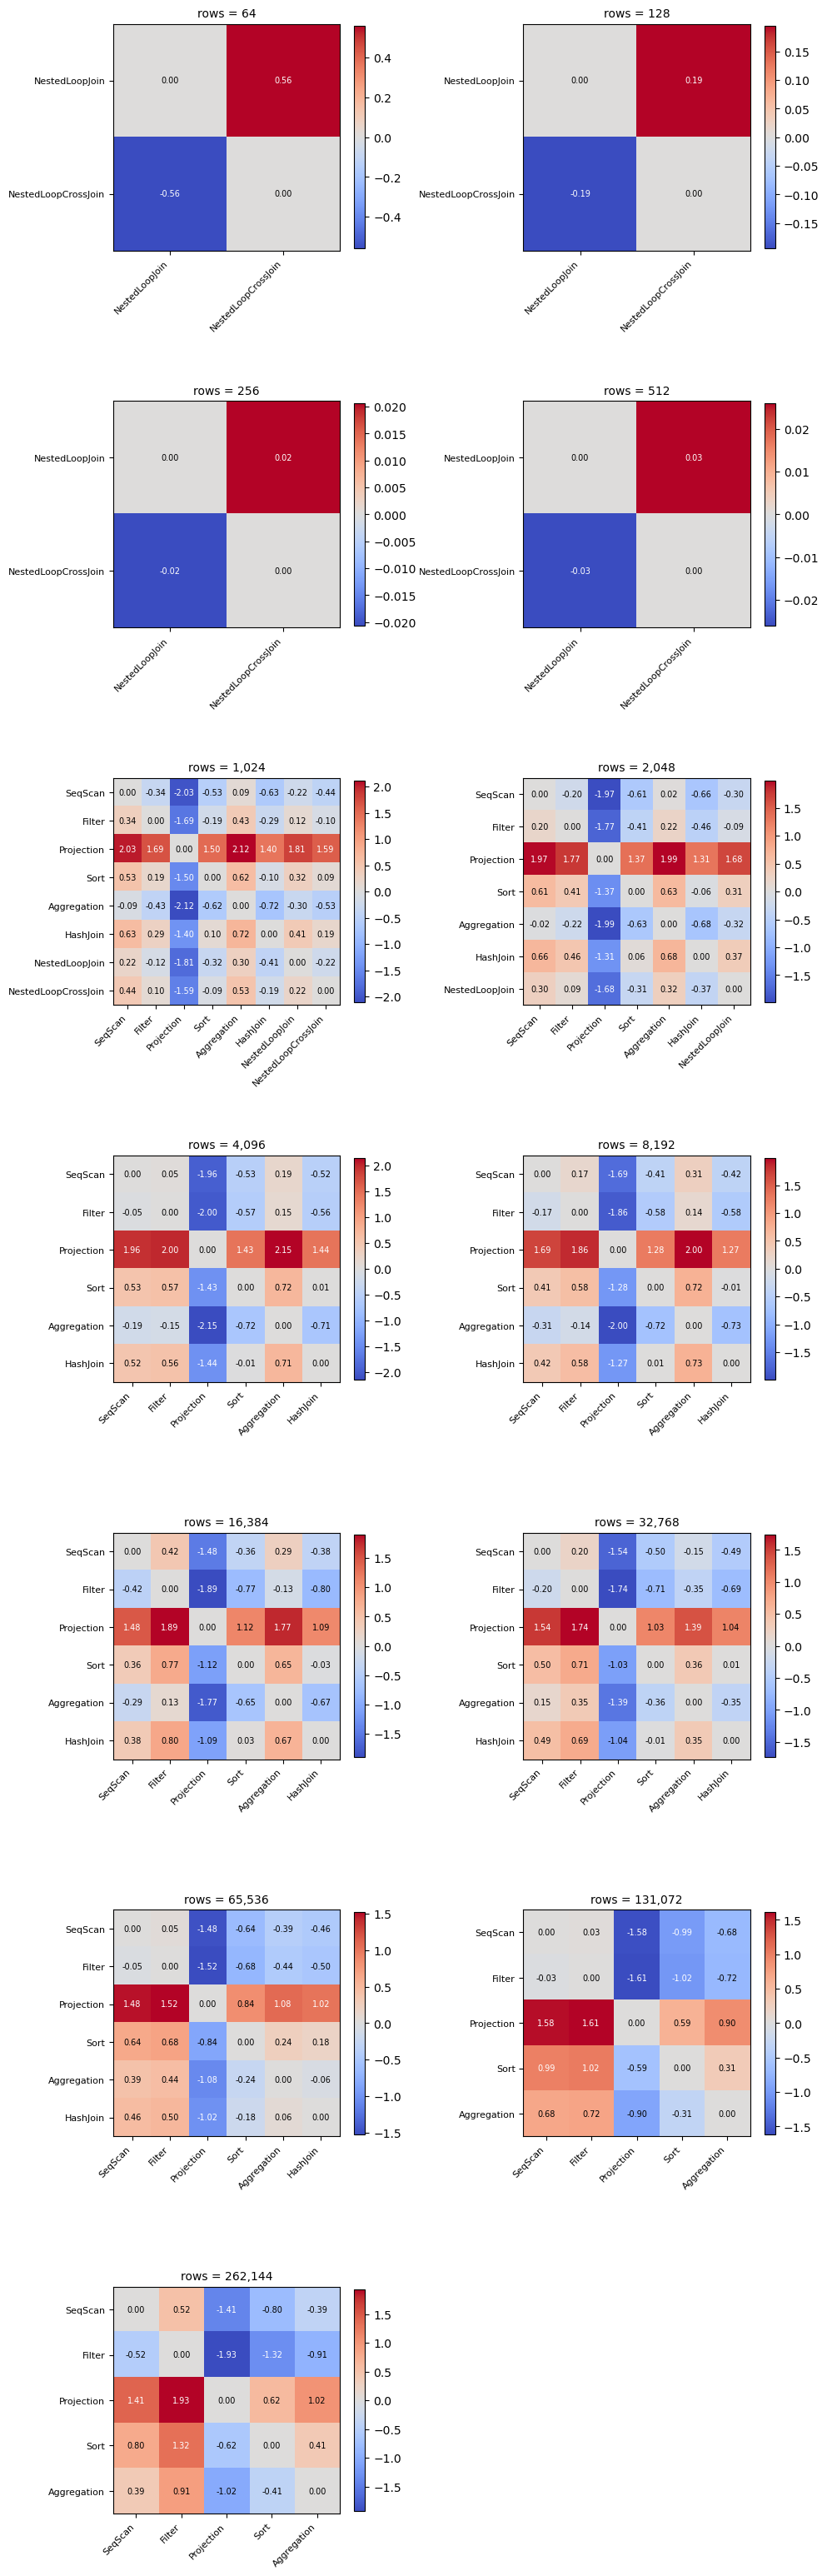

In [6]:
import matplotlib.pyplot as plt
import numpy as np

pivot = df.set_index(['operator', 'left_rows'])[['cpu_time', 'model_cost']]

all_counts = sorted(df['left_rows'].unique())
valid_counts = [rc for rc in all_counts
                if pivot.index.get_level_values('left_rows').isin([rc]).sum() >= 2]

ncols = 2
nrows = (len(valid_counts) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

for idx, rc in enumerate(valid_counts):
    ax = axes[idx // ncols][idx % ncols]
    sub = pivot.xs(rc, level='left_rows')
    ops = sub.index.tolist()
    m = len(ops)

    mat = np.zeros((m, m))
    for i, a in enumerate(ops):
        for j, b in enumerate(ops):
            if i != j:
                mat[i, j] = (np.log(sub.loc[a, 'cpu_time'])   - np.log(sub.loc[b, 'cpu_time']) -
                             (np.log(sub.loc[a, 'model_cost']) - np.log(sub.loc[b, 'model_cost'])))

    vmax = np.abs(mat).max() or 1.0
    im = ax.imshow(mat, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(m)); ax.set_xticklabels(ops, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(m)); ax.set_yticklabels(ops, fontsize=8)
    ax.set_title(f'rows = {rc:,}', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(m):
        for j in range(m):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(mat[i,j]) < vmax * 0.6 else 'white')

for idx in range(len(valid_counts), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
rows = []
for rc in valid_counts:
    sub = pivot.xs(rc, level='left_rows')
    ops = sub.index.tolist()
    for a in ops:
        for b in ops:
            if a != b:
                delta = (np.log(sub.loc[a, 'cpu_time'])   - np.log(sub.loc[b, 'cpu_time']) -
                        (np.log(sub.loc[a, 'model_cost']) - np.log(sub.loc[b, 'model_cost'])))
                rows.append({'row_count': rc, 'a': a, 'b': b, 'delta': delta})

comparison = pd.DataFrame(rows)
comparison.pivot_table(index=['a', 'b'], columns='row_count', values='delta').round(3)

row_count                                64      128     256     512     \
a                   b                                                     
Aggregation         Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
Filter              Aggregation             NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
HashJoin            Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
NestedLoopCrossJoin Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopJoin       -0.559  -0.194  -0.021  -0.026   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
NestedLoopJoin      Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin   0.559   0.194   0.021   0.026   
                    Projection              NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
Projection          Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    SeqScan                 NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
SeqScan             Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJoin                NaN     NaN     NaN     NaN   
                    NestedLoopCrossJoin     NaN     NaN     NaN     NaN   
                    NestedLoopJoin          NaN     NaN     NaN     NaN   
                    Projection              NaN     NaN     NaN     NaN   
                    Sort                    NaN     NaN     NaN     NaN   
Sort                Aggregation             NaN     NaN     NaN     NaN   
                    Filter                  NaN     NaN     NaN     NaN   
                    HashJ

In [8]:
!cd ~/c/iu9-sql-compiler/ && ./build-release/bin/benchmarks --benchmark_filter='OperatorCostMatched*' --benchmark_out=/tmp/operator-cost-matched.json --benchmark_out_format=json

2026-05-31T16:16:05+03:00
Running ./build-release/bin/benchmarks
Run on (8 X 4200 MHz CPU s)
CPU Caches:
  L1 Data 48 KiB (x4)
  L1 Instruction 32 KiB (x4)
  L2 Unified 1280 KiB (x4)
  L3 Unified 8192 KiB (x1)
Load Average: 3.38, 2.81, 1.77
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
-----------------------------------------------------------------------------------------------------------------------------------------
Benchmark                                                                               Time             CPU   Iterations UserCounters...
-----------------------------------------------------------------------------------------------------------------------------------------
OperatorCostMatched/target_cost:640000/SeqScan/6400/real_time                      532418 ns       521056 ns         1116 model_cost=640k output_rows=6.4k plan_cost=640k rows=6.4k
OperatorCostMatched/target_cost:640000/Filter/

In [9]:
import json
results = None
with open('/tmp/operator-cost-matched.json') as f:
    results = json.load(f)

results

{'context': {'date': '2026-05-31T16:16:05+03:00',
  'host_name': 'nixos',
  'executable': './build-release/bin/benchmarks',
  'num_cpus': 8,
  'mhz_per_cpu': 4200,
  'cpu_scaling_enabled': True,
  'caches': [{'type': 'Data', 'level': 1, 'size': 49152, 'num_sharing': 2},
   {'type': 'Instruction', 'level': 1, 'size': 32768, 'num_sharing': 2},
   {'type': 'Unified', 'level': 2, 'size': 1310720, 'num_sharing': 2},
   {'type': 'Unified', 'level': 3, 'size': 8388608, 'num_sharing': 8}],
  'load_avg': [3.37842, 2.81006, 1.77441],
  'library_version': 'v1.9.0',
  'library_build_type': 'release',
  'json_schema_version': 1},
 'benchmarks': [{'name': 'OperatorCostMatched/target_cost:640000/SeqScan/6400/real_time',
   'family_index': 0,
   'per_family_instance_index': 0,
   'run_name': 'OperatorCostMatched/target_cost:640000/SeqScan/6400/real_time',
   'run_type': 'iteration',
   'repetitions': 1,
   'repetition_index': 0,
   'threads': 1,
   'iterations': 1116,
   'real_time': 532417.982082007,

In [10]:
matched_df = pd.DataFrame(results['benchmarks'])
matched_df = matched_df[matched_df['run_type'] == 'iteration'].copy()

parts = matched_df['name'].str.split('/')
matched_df['target_cost'] = parts.str[1].str.removeprefix('target_cost:').astype(int)
matched_df['operator'] = parts.str[2]
matched_df['left_rows'] = parts.str[3].astype(int)
matched_df['right_rows'] = parts.apply(lambda p: int(p[4]) if len(p) == 6 else None)
matched_df['real_time_ms'] = matched_df['real_time'] / 1e6

matched_df['matching_error'] = (matched_df['model_cost'] - matched_df['target_cost']).abs() / matched_df['target_cost']
assert (matched_df['matching_error'] < 0.02).all()

matched_df[['target_cost', 'operator', 'left_rows', 'right_rows', 'real_time_ms', 'model_cost', 'plan_cost', 'matching_error']].sort_values(['target_cost', 'operator'])

,target_cost,operator,left_rows,right_rows,real_time_ms,model_cost,plan_cost,matching_error
4,640000,Aggregation,1255,NaN,0.529187,640050.0,765550.0,7.812500e-05
1,640000,Filter,6400,NaN,0.508270,640000.0,1280000.0,0.000000e+00
5,640000,HashJoin,4638,4638.0,1.026885,640044.0,1567644.0,6.875000e-05
7,640000,NestedLoopCrossJoin,78,78.0,0.527338,632736.0,648336.0,1.135000e-02
6,640000,NestedLoopJoin,96,96.0,0.875389,645120.0,664320.0,8.000000e-03
2,640000,Projection,29091,NaN,4.068856,640002.0,3549102.0,3.125000e-06
0,640000,SeqScan,6400,NaN,0.532418,640000.0,640000.0,0.000000e+00
3,640000,Sort,4476,NaN,0.997566,640068.0,1087668.0,1.062500e-04
12,1000000,Aggregation,1961,NaN,0.702024,1000110.0,1196210.0,1.100000e-04
9,1000000,Filter,10000,NaN,0.861315,1000000.0,2000000.0,0.000000e+00


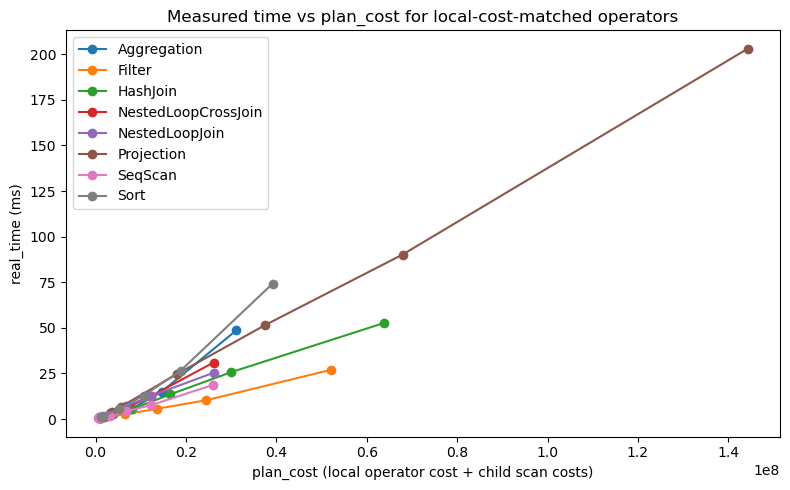

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for op, grp in matched_df.groupby('operator'):
    grp = grp.sort_values('plan_cost')
    ax.plot(grp['plan_cost'], grp['real_time_ms'], marker='o', label=op)

ax.set_xlabel('plan_cost (local operator cost + child scan costs)')
ax.set_ylabel('real_time (ms)')
ax.set_title('Measured time vs plan_cost for local-cost-matched operators')
ax.legend()
plt.tight_layout()
plt.show()

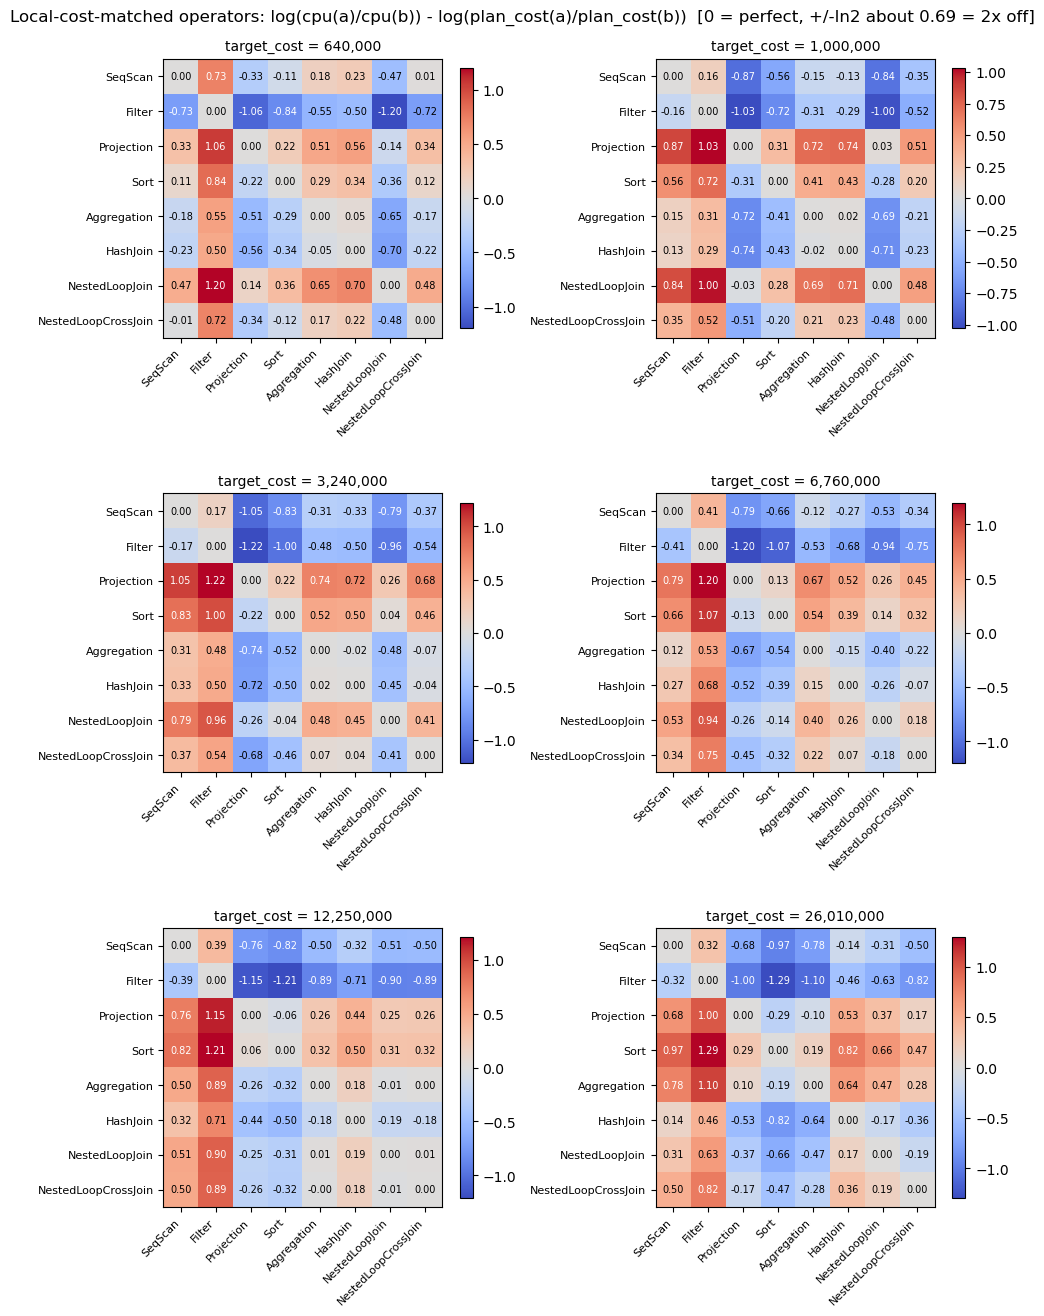

In [12]:
matched_pivot = matched_df.set_index(['target_cost', 'operator'])[['cpu_time', 'model_cost', 'plan_cost']]
matched_costs = sorted(matched_df['target_cost'].unique())

ncols = 2
nrows = (len(matched_costs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

for idx, target_cost in enumerate(matched_costs):
    ax = axes[idx // ncols][idx % ncols]
    sub = matched_pivot.xs(target_cost, level='target_cost')
    ops = sub.index.tolist()
    m = len(ops)

    mat = np.zeros((m, m))
    for i, a in enumerate(ops):
        for j, b in enumerate(ops):
            if i != j:
                mat[i, j] = (np.log(sub.loc[a, 'cpu_time']) - np.log(sub.loc[b, 'cpu_time']) -
                             (np.log(sub.loc[a, 'plan_cost']) - np.log(sub.loc[b, 'plan_cost'])))

    vmax = np.abs(mat).max() or 1.0
    im = ax.imshow(mat, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(m)); ax.set_xticklabels(ops, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(m)); ax.set_yticklabels(ops, fontsize=8)
    ax.set_title(f'target_cost = {target_cost:,}', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(m):
        for j in range(m):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(mat[i,j]) < vmax * 0.6 else 'white')

for idx in range(len(matched_costs), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle('Local-cost-matched operators: log(cpu(a)/cpu(b)) - log(plan_cost(a)/plan_cost(b))  [0 = perfect, +/-ln2 about 0.69 = 2x off]', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
matched_rows = []
for target_cost in matched_costs:
    sub = matched_pivot.xs(target_cost, level='target_cost')
    ops = sub.index.tolist()
    for a in ops:
        for b in ops:
            if a != b:
                delta = (np.log(sub.loc[a, 'cpu_time']) - np.log(sub.loc[b, 'cpu_time']) -
                         (np.log(sub.loc[a, 'plan_cost']) - np.log(sub.loc[b, 'plan_cost'])))
                matched_rows.append({'target_cost': target_cost, 'a': a, 'b': b, 'delta': delta})

matched_comparison = pd.DataFrame(matched_rows)
matched_comparison.pivot_table(index=['a', 'b'], columns='target_cost', values='delta').round(3)

target_cost                              640000    1000000   3240000   \
a                   b                                                   
Aggregation         Filter                  0.552     0.312     0.478   
                    HashJoin                0.047     0.021    -0.025   
                    NestedLoopCrossJoin    -0.169    -0.206    -0.065   
                    NestedLoopJoin         -0.651    -0.688    -0.479   
                    Projection             -0.508    -0.718    -0.743   
                    SeqScan                -0.180     0.149     0.307   
                    Sort                   -0.290    -0.409    -0.523   
Filter              Aggregation            -0.552    -0.312    -0.478   
                    HashJoin               -0.504    -0.290    -0.502   
                    NestedLoopCrossJoin    -0.721    -0.517    -0.543   
                    NestedLoopJoin         -1.203    -0.999    -0.956   
                    Projection             -1.059    -1.030    -1.220   
                    SeqScan                -0.732    -0.162    -0.171   
                    Sort                   -0.841    -0.720    -1.000   
HashJoin            Aggregation            -0.047    -0.021     0.025   
                    Filter                  0.504     0.290     0.502   
                    NestedLoopCrossJoin    -0.217    -0.227    -0.041   
                    NestedLoopJoin         -0.698    -0.709    -0.454   
                    Projection             -0.555    -0.740    -0.718   
                    SeqScan                -0.227     0.128     0.331   
                    Sort                   -0.337    -0.430    -0.498   
NestedLoopCrossJoin Aggregation             0.169     0.206     0.065   
                    Filter                  0.721     0.517     0.543   
                    HashJoin                0.217     0.227     0.041   
                    NestedLoopJoin         -0.482    -0.482    -0.413   
                    Projection             -0.338    -0.512    -0.677   
                    SeqScan                -0.011     0.355     0.372   
                    Sort                   -0.121    -0.203    -0.457   
NestedLoopJoin      Aggregation             0.651     0.688     0.479   
                    Filter                  1.203     0.999     0.956   
                    HashJoin                0.698     0.709     0.454   
                    NestedLoopCrossJoin     0.482     0.482     0.413   
                    Projection              0.143    -0.030    -0.264   
                    SeqScan                 0.471     0.837     0.786   
                    Sort                    0.361     0.279    -0.044   
Projection          Aggregation             0.508     0.718     0.743   
                    Filter                  1.059     1.030     1.220   
                    HashJoin                0.555     0.740     0.718   
                    NestedLoopCrossJoin     0.338     0.512     0.677   
                    NestedLoopJoin         -0.143     0.030     0.264   
                    SeqScan                 0.328     0.867     1.049   
                    Sort                    0.218     0.309     0.220   
SeqScan             Aggregation             0.180    -0.149    -0.307   
                    Filter                  0.732     0.162     0.171   
                    HashJoin                0.227    -0.128    -0.331   
                    NestedLoopCrossJoin     0.011    -0.355    -0.372   
                    NestedLoopJoin         -0.471    -0.837    -0.786   
                    Projection             -0.328    -0.867    -1.049   
                    Sort                   -0.110    -0.558    -0.830   
Sort                Aggregation             0.290     0.409     0.523   
                    Filter                  0.841     0.720     1.000   
                    HashJoin                0.337     0.430     0.498   
                    NestedLoopCrossJoin     0.121     0.20